# Assignment 2
## Part 2 - Evaluating time series

### 2A - Single series: seasonal cycle and trend

In [1]:
import numpy as np

%load_ext autoreload

In [2]:
from amocatlas import read

transports = read.rapid()
trans_umo = transports.TRANS_UMO
moc = transports.MOC

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



#### Compute and remove the seasonal cycle — show the monthly climatology

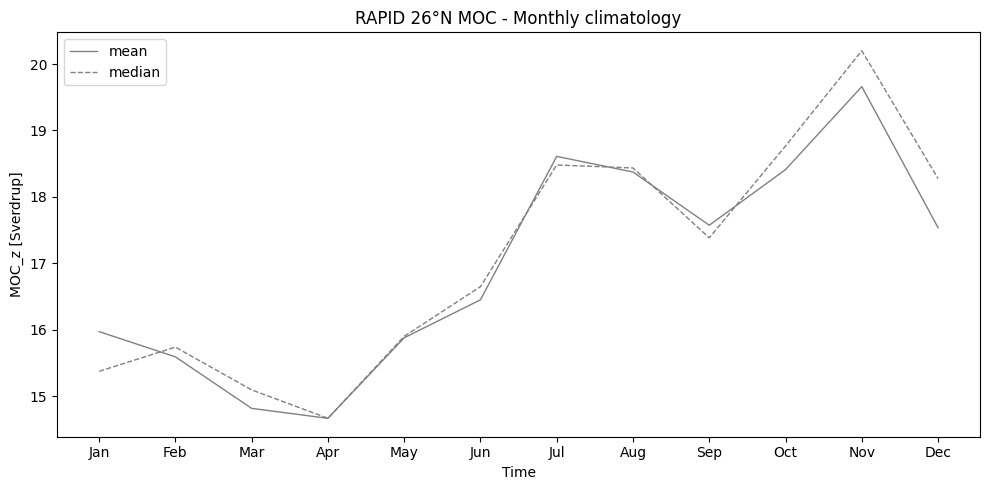

In [3]:
from amoc_analysis.spectra_filtering.analysis import seasonal_cycle
import matplotlib.pyplot as plt

# Compute climatology
moc_clim = seasonal_cycle(moc.TIME, moc.values)
moc_clim.insert(0, 'month', ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Plot monthly climatology
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(moc_clim['mean'], color="grey", ls='-', alpha=1, linewidth=1, label='mean')
ax.plot(moc_clim['median'], color="grey", ls='--', alpha=1, linewidth=1, label='median')

ax.set_title("RAPID 26°N MOC - Monthly climatology")
ax.set_ylabel('MOC_z [Sverdrup]')
ax.set_xlabel("Time")

ax.set_xticks(np.arange(1,13,1), labels=moc_clim['month'])

ax.legend()
plt.tight_layout()

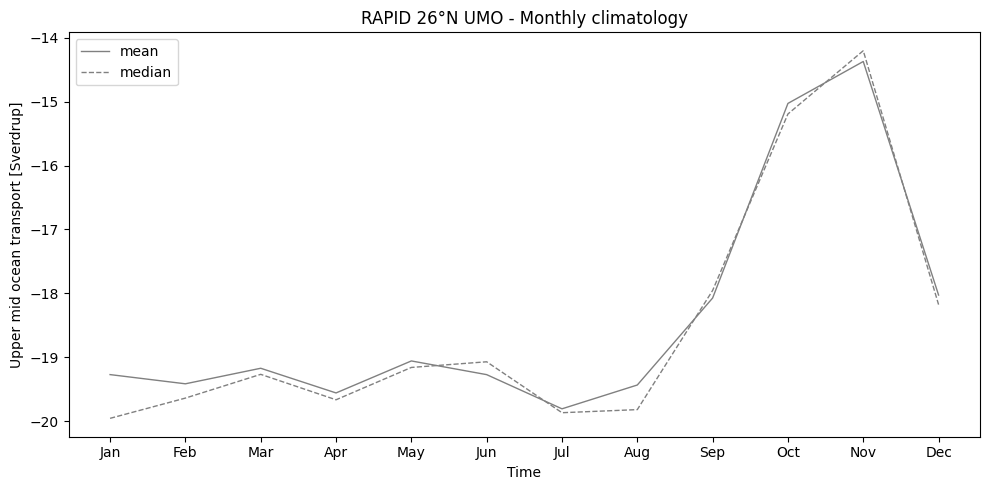

In [4]:
from amoc_analysis.spectra_filtering.analysis import seasonal_cycle
import matplotlib.pyplot as plt

# Compute seasonal cycle/climatology
trans_umo_clim = seasonal_cycle(trans_umo.TIME, trans_umo.values)
trans_umo_clim.insert(0, 'month', ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Plot climatology
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(trans_umo_clim['mean'], color="grey", ls='-', alpha=1, linewidth=1, label='mean')
ax.plot(trans_umo_clim['median'], color="grey", ls='--', alpha=1, linewidth=1, label='median')

ax.set_title("RAPID 26°N UMO - Monthly climatology")
ax.set_ylabel('Upper mid ocean transport [Sverdrup]')
ax.set_xlabel("Time")

ax.set_xticks(np.arange(1,13,1), labels=trans_umo_clim['month'])

ax.legend()
plt.tight_layout()

#### Plot the deseasonalised series with the overall mean kept

(draw the deseasonalised line darker and thicker over the raw series)

In [5]:
import xarray as xr

# Map seasonal means to full time period -> make func
months = trans_umo.TIME.dt.month
clim_by_month = dict(zip(range(1, 13), trans_umo_clim['mean']))  # if clim is 12 values
trans_umo_clim_full = xr.DataArray(
    [clim_by_month[m] for m in months.values],
    dims="TIME", coords={"TIME": trans_umo.TIME}
)

# Map seasonal means to full time period -> make func
months = moc.TIME.dt.month
clim_by_month = dict(zip(range(1, 13), moc_clim['mean']))  # if clim is 12 values
moc_clim_full = xr.DataArray(
    [clim_by_month[m] for m in months.values],
    dims="TIME", coords={"TIME": moc.TIME}
)

trans_umo_deseasoned = trans_umo - trans_umo_clim_full
moc_deseasoned = moc - moc_clim_full

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'RAPID 16N MOC'}, xlabel='Time', ylabel='MOC_z [Sverdrup]'>)

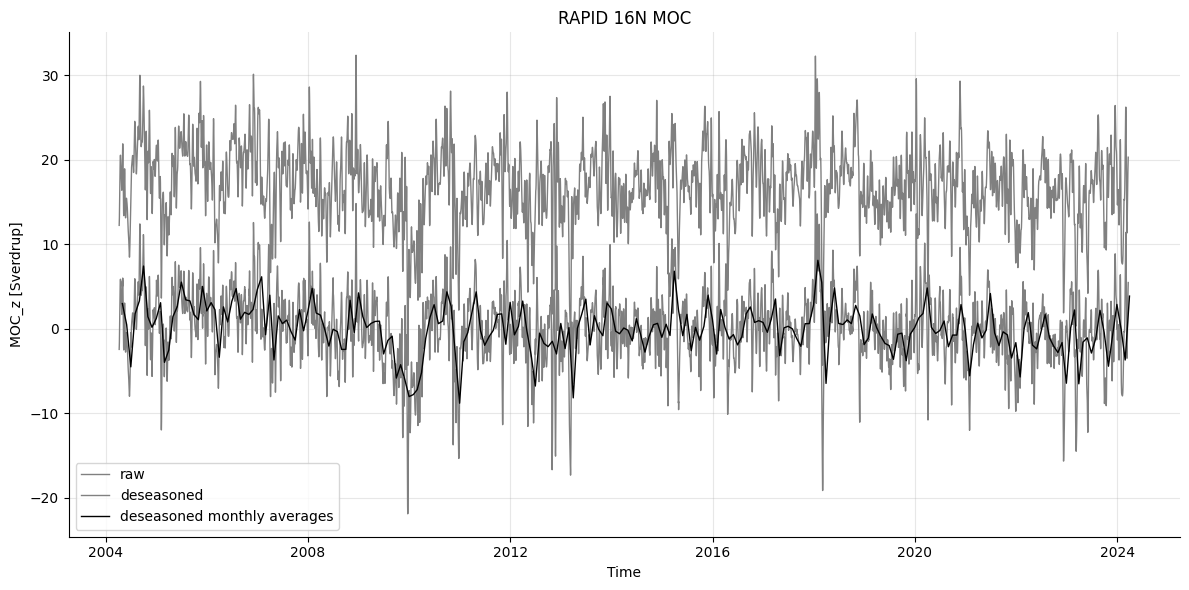

In [6]:
%autoreload
from amoc_analysis.plotting import plot_time_series_from_dataarray

# Deseasoned monthly averages
moc_monthly = moc_deseasoned.resample(TIME='ME').mean()

# Plot raw, deseasoned and deseasoned monthly averages
plot_time_series_from_dataarray([moc, moc_deseasoned, moc_monthly], 
    title='RAPID 16N MOC',
    ylabel='MOC_z [Sverdrup]',
    labels=['raw', 'deseasoned', 'deseasoned monthly averages'],
    colors=['grey', 'grey', 'k'],
    )

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'RAPID 16N UMO'}, xlabel='Time', ylabel='Upper mid-ocean transport [Sverdrup]'>)

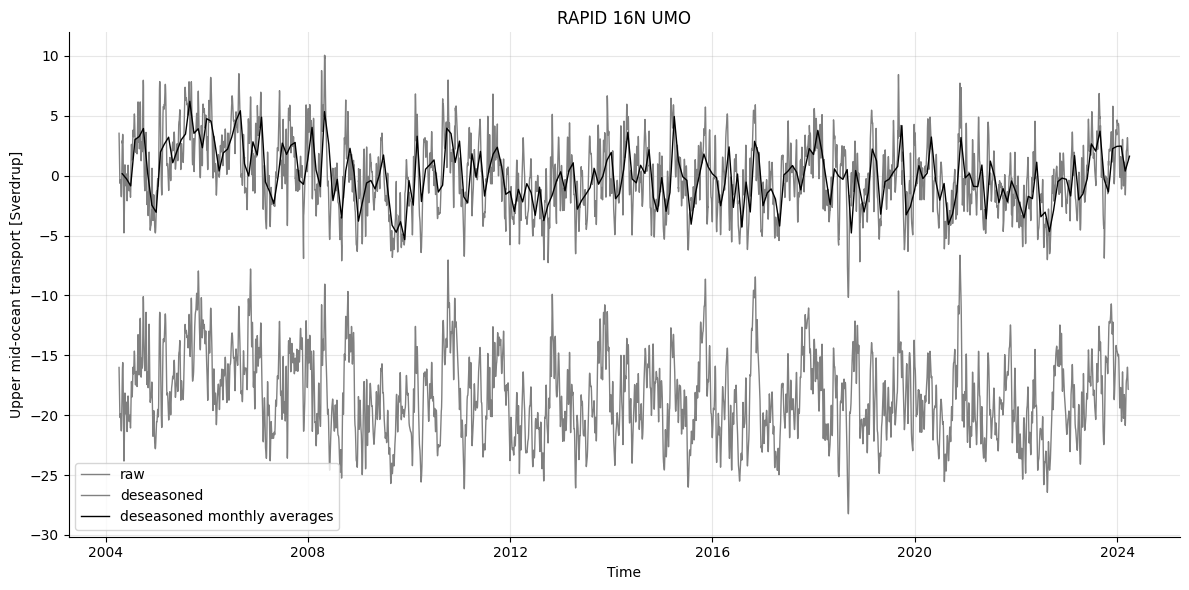

In [7]:
%autoreload
from amoc_analysis.plotting import plot_time_series_from_dataarray

# Deseasoned monthly averages
trans_umo_monthly = trans_umo_deseasoned.resample(TIME='ME').mean()

# Plot raw, deseasoned and deseasoned monthly averages
plot_time_series_from_dataarray([trans_umo, trans_umo_deseasoned, trans_umo_monthly], 
    title='RAPID 16N UMO',
    ylabel='Upper mid-ocean transport [Sverdrup]',
    labels=['raw', 'deseasoned', 'deseasoned monthly averages'],
    colors=['grey', 'grey', 'k'],
    )